# Import

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import uniform
from scipy.stats import bootstrap
from copy import deepcopy


In [2]:
mine_prop = gpd.read_file('data\mine-comm\snl_mining_properties.gpkg')
snl_prod = pd.read_csv('data\mine-comm\snl_production_values.csv')

In [3]:
mine_prop.head()

,mine,snl_id,known_as,primary_commodity,list_of_commodities,development_stage,operating_status,mine_type_1,mine_type_2,mine_type_3,country,coordinate_accuracy,geometry
0,101,64665,None,Coal,Coal,Operating,None,None,None,None,Brazil,Exact,POINT (-49.24552 -28.73240)
1,1068,79522,None,Gold,"Gold,Copper,Molybdenum",Exploration,Active,None,None,None,Mexico,Best Guess,POINT (-109.32652 29.06976)
2,11 RAU-Novaya,68289,None,Coal,Coal,Grassroots,Inactive,None,None,None,Ukraine,Best Guess,POINT (38.65827 48.51954)
3,1165L,63154,None,Coal,Coal,Advanced Exploration,Inactive,Open Pit,None,None,Mozambique,Exact,POINT (34.00000 -16.23000)
4,119 Property,32960,"866119/00, Aripuana 3 Cluster, ARP-03 Cluster,...",Diamonds,Diamonds,Exploration,Inactive,Placer,None,None,Brazil,Exact,POINT (-58.83353 -11.48279)


In [4]:
mine_prop.development_stage.value_counts()

development_stage
Exploration             7464
Operating               5396
Grassroots              5134
Target Outline          4648
Reserves Development    4005
Closed                  1634
Advanced Exploration    1112
Prefeas/Scoping          913
Feasibility              677
Satellite                535
Expansion                313
Preproduction            281
Limited Production       233
Feasibility Complete     204
Feasibility Started      200
Construction Started     178
Construction Planned      94
Commissioning             31
Residual Production       26
Name: count, dtype: int64

Well we have to assess what development stages have what production volume.

Filter for year 2017 as it is the year where also the indigenous territory data was aquired

In [5]:
snl_prod.head()
snl_prod17 = snl_prod[snl_prod.year == 2017]

In [6]:
snl_prod17.shape

(1319975, 5)

In [7]:
snl_prod17.columns

Index(['snl_id', 'commodity', 'year', 'value', 'unit'], dtype='object')

In [8]:
snl_prod17[~snl_prod17.isna()].count() / snl_prod.shape[0] *100

snl_id       24.503311
commodity    24.503311
year         24.503311
value         0.062540
unit         24.503311
dtype: float64

In [11]:
snl_prod17.count() / snl_prod17.shape[0] *100

snl_id       100.000000
commodity    100.000000
year         100.000000
value          0.255232
unit         100.000000
dtype: float64

We can assess that only .26% of the mines recorded in the dataset have not none values. This and 0 values are of no information for the weight calculation. 

In [12]:
snl_filter = snl_prod17[~snl_prod17.value.isna() & ~snl_prod17.value.isnull()]

In [13]:
snl_filter.shape

(3369, 5)

As a result we can conclude we have 3369 mines satisfying the conditions. However these are not too much mines. Lets check 2016 and 2018 also if we can increase the sample size.

In [17]:
snl_filterextend = snl_prod[~snl_prod.value.isna() & ~snl_prod.value.isnull()]

In [18]:
snl_filterextend.groupby('year').count()

,snl_id,commodity,value,unit
year,,,,
2015,3897,3897,3897,3897
2016,3482,3482,3482,3482
2017,3369,3369,3369,3369
2018,3397,3397,3397,3397


Well we see the numbers are not altering significantly. Therefore we ommit the analysis of previouse years. However the relative share distirbution analysis would be enriched by checking if the mean is significantly different from the other years.

In [24]:
# Ensure 'snl_id' is of the same type in both DataFrames
mine_prop['snl_id'] = mine_prop['snl_id'].astype(str)
snl_filterextend['snl_id'] = snl_filterextend['snl_id'].astype(str)

# Merge the DataFrames
vsnl_join = mine_prop.merge(snl_filterextend, on='snl_id')

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\931701435.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snl_filterextend['snl_id'] = snl_filterextend['snl_id'].astype(str)


In [28]:
vsnl_join.shape
vsnl_join.columns

Index(['mine', 'snl_id', 'known_as', 'primary_commodity',
       'list_of_commodities', 'development_stage', 'operating_status',
       'mine_type_1', 'mine_type_2', 'mine_type_3', 'country',
       'coordinate_accuracy', 'geometry', 'commodity', 'year', 'value',
       'unit'],
      dtype='object')

In [40]:
vsnl_sub = vsnl_join[['snl_id', 'mine', 'value', 'unit', 'year', 'commodity', 'list_of_commodities', 'development_stage']]

we see the units are not harmonized. lets fix that

In [43]:
vsnl_sub.unit.value_counts()

unit
tonne    8430
oz       4619
lb        204
ct        183
Name: count, dtype: int64

In [48]:
conversion_factors = {
    'tonne': 1,
    'oz': 2.83495e-5, # 1 troy ounce = 2.83495e-5 tonnes
    'lb': 0.000453592, # 1 pound = 0.000453592 tonnes
    'ct': 2e-7 # 1 carat = 2e-7 tonnes
    }

def convert_to_tonnes(row):
    value_in_tonnes = row['value'] * conversion_factors[row['unit']]
    return value_in_tonnes


vsnl_harmo = vsnl_sub.copy()


vsnl_harmo['value'] = vsnl_harmo.apply(convert_to_tonnes, axis=1)

In [49]:
vsnl_harmo['unit'] = 'tonne'

We also observed some 0.0 values. As this is not of any help lets filter them out.

In [54]:
vsnl_filter = vsnl_harmo[~(vsnl_harmo.value ==0)]

In [55]:
vsnl_filter.shape

(13017, 8)

Lets check also on the development status of the projects

In [59]:
dev_status_year = vsnl_filter.groupby('year')['development_stage'].value_counts().reset_index()

In [74]:
# Pivot the DataFrame
pivot_df = dev_status_year.pivot(index='development_stage', columns='year', values='count')

# Fill missing values with 0 (if needed)
pivot_df = pivot_df.fillna(0).astype(int) / pivot_df.sum(axis=0) * 100


pivot_df.round(2)

year,2015,2016,2017,2018
development_stage,,,,
Advanced Exploration,0.11,0.09,0.07,0.07
Closed,3.16,1.49,0.81,0.46
Commissioning,0.11,0.06,0.13,0.39
Construction Planned,0.00,0.00,0.00,0.03
Construction Started,0.22,0.19,0.36,0.75
Expansion,10.44,11.93,12.78,12.91
Exploration,0.00,0.00,0.07,0.07
Feasibility,0.11,0.19,0.23,0.39
Feasibility Complete,0.16,0.19,0.16,0.20


In [77]:
# Export to LaTeX
latex_table = pivot_df.to_latex(index=True)

# Write the LaTeX table to a file
with open('tabs/table_dev_stage_yearly.tex', 'w') as f:
    f.write(latex_table)


Methodological choice: Concentration on Expansion and Operating development stages. Reasons:

1. Validity that production is really production and not only exploration
2. other development stages not uniquely defined
3. >90\% of the operations observations are coverd.

In [88]:
pivot_df.loc[['Expansion', 'Operating'],:].sum()

year
2015    89.640011
2016    92.080745
2017    92.209909
2018    91.925466
dtype: float64

In [89]:
vsnl_dev = vsnl_filter[vsnl_filter.development_stage.isin(['Operating', 'Expansion'])]

In [90]:
vsnl_dev.columns

Index(['snl_id', 'mine', 'value', 'unit', 'year', 'commodity',
       'list_of_commodities', 'development_stage'],
      dtype='object')

In [98]:
share = (vsnl_dev.groupby(['snl_id', 'year', 'commodity' ])
              .agg({'value': 'sum'}).round(1)
              .reset_index())



share['value_total'] = share.groupby(['snl_id', 'year'])['value'].transform('sum').round(1)
share['share'] = share['value'] / share['value_total'].round(2)



In [99]:
share

,snl_id,year,commodity,value,value_total,share
0,24450,2015,Gold,3.6,3.6,1.000000
1,24450,2016,Gold,3.5,3.5,1.000000
2,24450,2017,Gold,3.3,3.3,1.000000
3,24450,2018,Gold,3.0,3.0,1.000000
4,24470,2015,Copper,60412.0,60509.3,0.998392
...,...,...,...,...,...,...
11863,81649,2017,Copper,1125.0,1125.0,1.000000
11864,81649,2018,Copper,1030.0,1030.0,1.000000
11865,81769,2016,Coal,200000.0,200000.0,1.000000
11866,81769,2017,Coal,500000.0,500000.0,1.000000


In [100]:
share.commodity.value_counts()

commodity
Gold                   2524
Coal                   2076
Copper                 1455
Silver                 1161
Iron Ore                993
Zinc                    880
Lead                    773
Nickel                  278
U3O8                    180
Bauxite                 174
Molybdenum              172
Platinum                150
Diamonds                139
Palladium               109
Cobalt                  109
Manganese               105
Potash                   76
Rhodium                  74
Phosphate                74
Lithium                  61
Ruthenium                43
Iridium                  42
Zircon                   38
Rutile                   31
Chromite                 30
Tin                      30
Ilmenite                 23
Tungsten                 18
Vanadium                 12
Titanium                  7
Lanthanides               7
Antimony                  5
Niobium                   4
Magnesium                 4
Tellurium                 4
Heavy Mine

Now we produce boxplots for the commodities with the highest volumnes per year.

In [161]:
def yearly_box_plot(df, years):
    for y in years:
        df_y = df[df.year == y]
        high_volume_com = df_y.groupby('commodity').filter(lambda x: x['value'].sum() > 10**5 )  # we plot only commodities with total production > 1000 tonnes
        
        high_volume_com_adjusted = high_volume_com[~high_volume_com.commodity.isin(['Heavy Mineral Sands'])]  # Remove Gold from the list of commodities
        df_filter = df_y[df_y.commodity.isin(high_volume_com_adjusted.commodity)]
        
        plt.figure(figsize=(16, 6))
        sns.boxplot(x='commodity', y='share', data=df_filter, palette='colorblind', showfliers=False)
        sns.stripplot(data=df_filter, x="commodity", y="share", size=4, color=".3")

        # Annotate with sample size
        n_obs = df_filter['commodity'].value_counts()
        for i, commodity in enumerate(n_obs.index):
            plt.text(i, 1 + 0.02,  # Adjust 0.01 for spacing
                     f'n={n_obs[commodity]}', 
                     horizontalalignment='center', 
                     size='medium', 
                     color='black')
        
        plt.title(f'Share of production by commodity in {y}')
        plt.ylabel('Share of production')
        plt.xlabel('Commodity')
        plt.xticks(rotation=45)
        sns.despine(trim=True, left=True)
        plt.subplots_adjust(top=1.1)
        plt.savefig(f'fig/boxplot_share_{y}.png')
        plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2834715553.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='commodity', y='share', data=df_filter, palette='colorblind', showfliers=False)


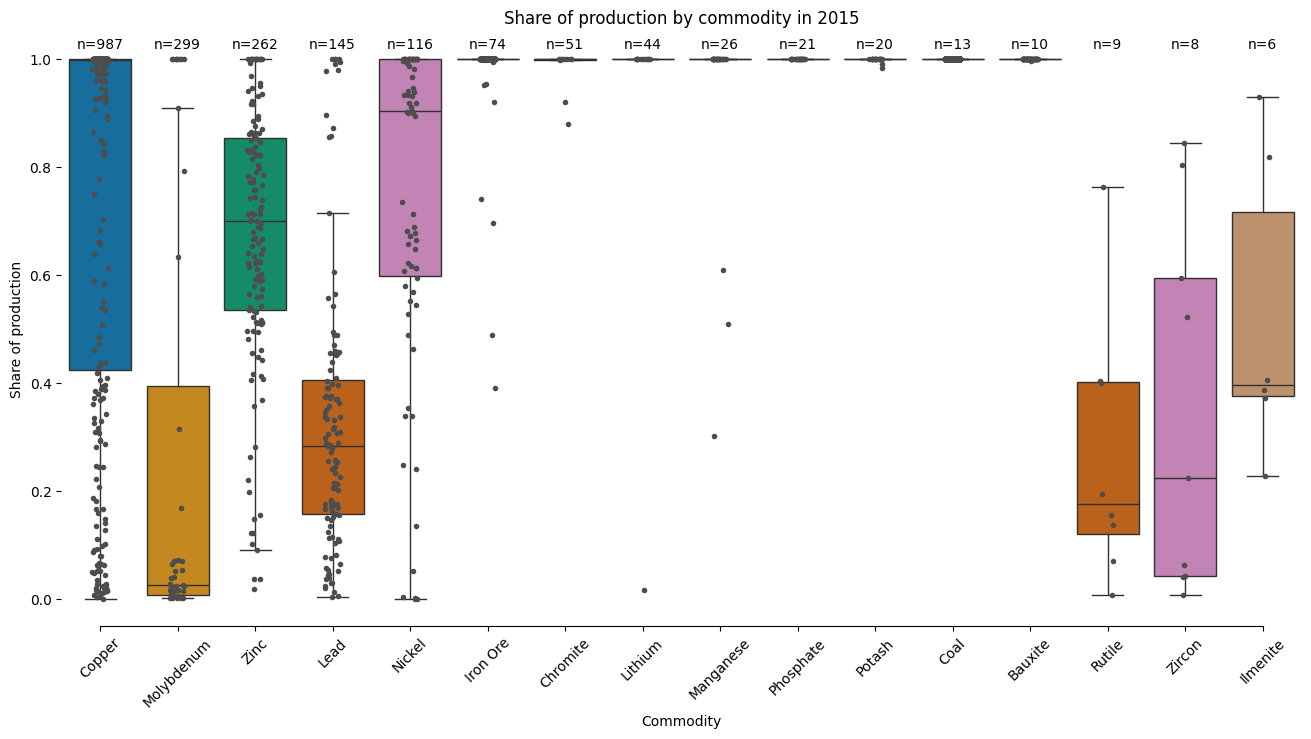

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2834715553.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='commodity', y='share', data=df_filter, palette='colorblind', showfliers=False)


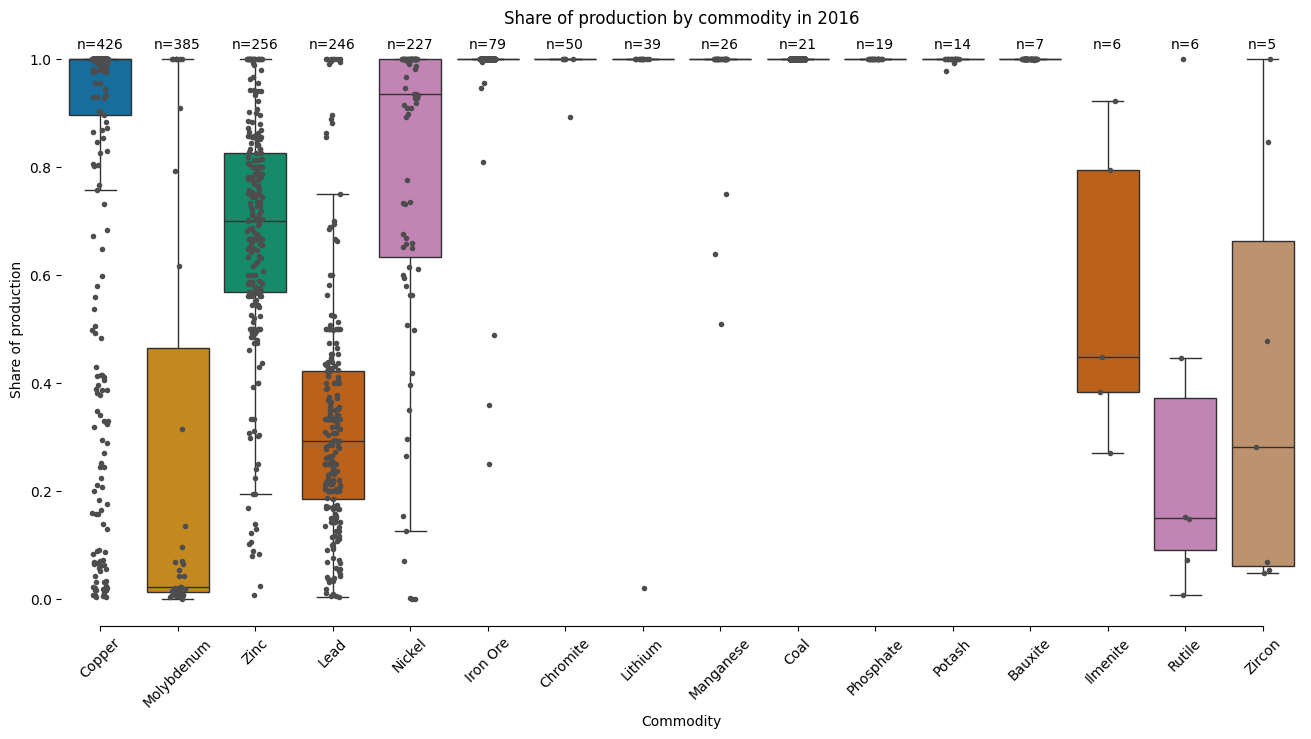

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2834715553.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='commodity', y='share', data=df_filter, palette='colorblind', showfliers=False)


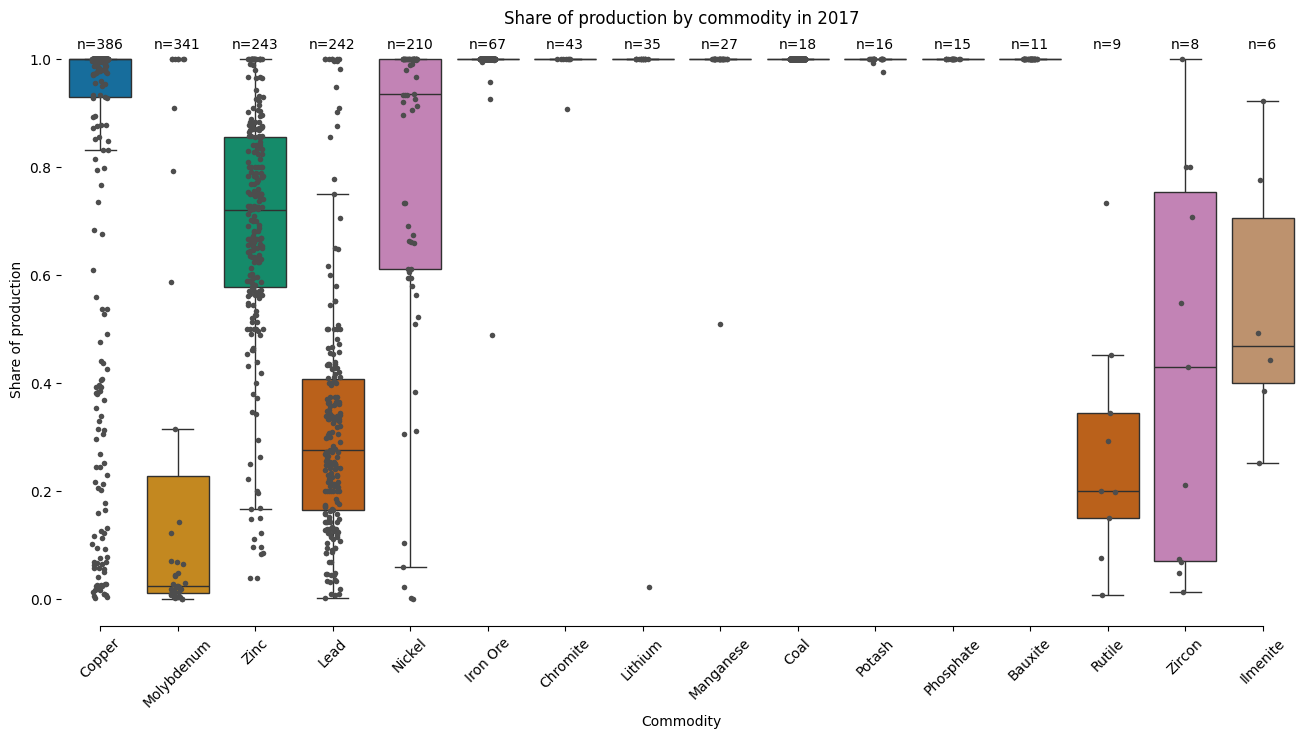

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2834715553.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='commodity', y='share', data=df_filter, palette='colorblind', showfliers=False)


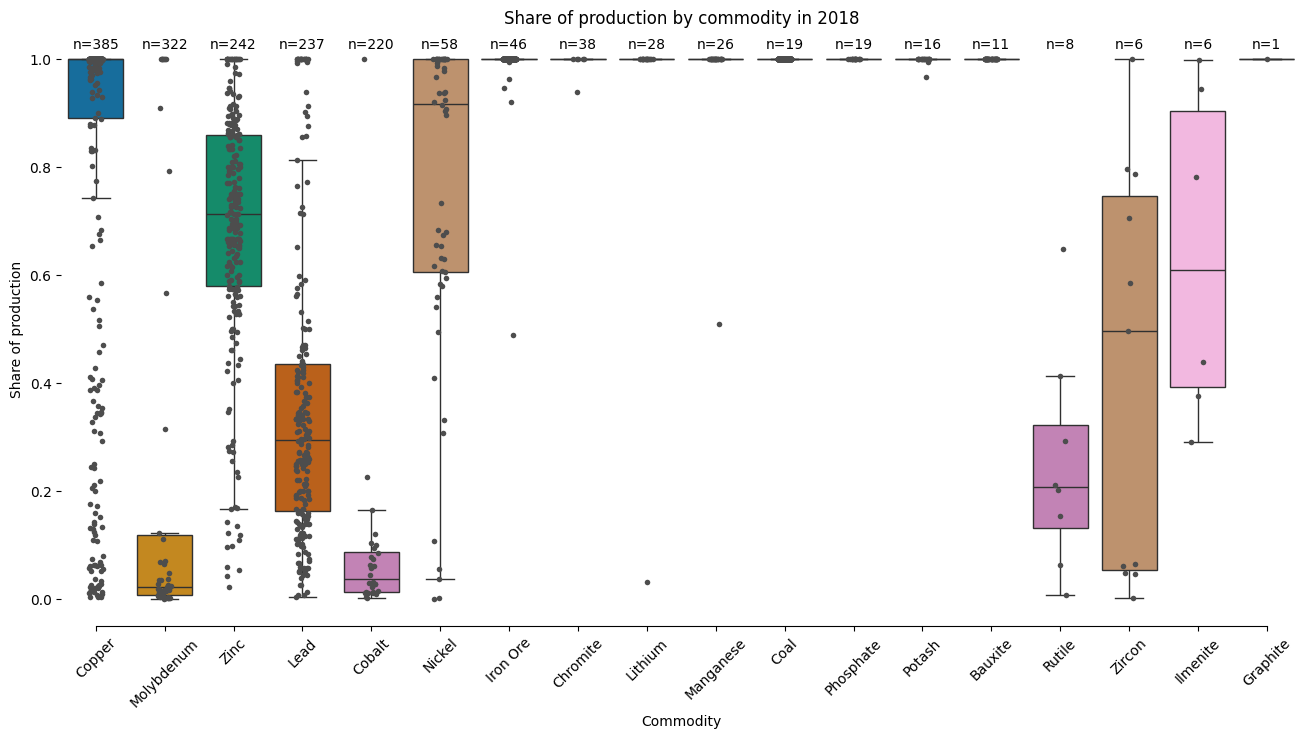

In [162]:
yearly_box_plot(share,np.arange(2015, 2019))

lets create also a table with summary statistics for every commodity share. 

Statistical parameters are:

* mean
* std
* sample size

In [199]:
def share_stat_par(df):
    df_com = df.groupby(['commodity','year']).agg(
        min_share=('share', 'min'),
        max_share=('share', 'max'),
        mean_share=('share', 'mean'),
        std_share=('share', 'std'),
        sample_size=('share', 'count')
    ).round(2)

    # Export to LaTeX
    latex_table = df_com.to_latex(index=True)

    # Write the LaTeX table to a file
    with open('tabs/com_share_stats.tex', 'w') as f:
         f.write(latex_table)


    return df_com

In [200]:
share_stat_par(share)

min_share  max_share  mean_share  std_share  sample_size
commodity year                                                          
Antimony  2015       1.00       1.00        1.00        NaN            1
          2016       1.00       1.00        1.00       0.00            2
          2017       1.00       1.00        1.00        NaN            1
          2018       1.00       1.00        1.00        NaN            1
Bauxite   2015       1.00       1.00        1.00       0.00           51
...                   ...        ...         ...        ...          ...
Zinc      2018       0.02       1.00        0.69       0.23          237
Zircon    2015       0.01       0.84        0.35       0.34            9
          2016       0.05       1.00        0.40       0.39            7
          2017       0.01       1.00        0.43       0.36           11
          2018       0.00       1.00        0.42       0.38           11

[147 rows x 5 columns]

Now we want to estimate the statistical parameters of the population meaning for every commodity and every year

In [171]:
share

,snl_id,year,commodity,value,value_total,share
0,24450,2015,Gold,3.6,3.6,1.000000
1,24450,2016,Gold,3.5,3.5,1.000000
2,24450,2017,Gold,3.3,3.3,1.000000
3,24450,2018,Gold,3.0,3.0,1.000000
4,24470,2015,Copper,60412.0,60509.3,0.998392
...,...,...,...,...,...,...
11863,81649,2017,Copper,1125.0,1125.0,1.000000
11864,81649,2018,Copper,1030.0,1030.0,1.000000
11865,81769,2016,Coal,200000.0,200000.0,1.000000
11866,81769,2017,Coal,500000.0,500000.0,1.000000


In [180]:
def commodity_bootstrap(data, stat=np.mean, con_levels=[0.9, 0.95, 0.99], **kwargs):
    data = np.array(data)
    result = []

    sample_size = len(data)

    if len(data) < 2:
        result = [(sample_size, _, (0, 1), np.nan) for _ in con_levels]

    elif len(np.unique(data)) == 1:
        share = float(np.unique(data))
        result = [(sample_size, _, (share, share), 0 ) for _ in con_levels]

    else:
        for con_level in con_levels:
            boot = bootstrap((data,), statistic=stat, confidence_level=con_level)
            conf_interval = boot.confidence_interval
            conf_interval_round = tuple(round(bound, 2) for bound in conf_interval)

            res.append((sample_size, con_level, boot.confidence_interval, boot.standard_error))

    return result

# Apply the commodity_bootstrap function to each group and concatenate the resulting DataFrames
share_boot = (share.groupby(['commodity', 'year'])['share']
              .apply(lambda x: pd.DataFrame(commodity_bootstrap(x)))
              .reset_index(level=-1, drop=True)
              .reset_index()
              .rename(columns={0:'sample_size', 1: 'conf_level', 2: 'conf_interval', 3: 'std_error'})
)


# Expand the tuples into separate columns and rename columns for clarity

share_boot[['lower_bound', 'upper_bound']] = pd.DataFrame(share_boot['conf_interval'].tolist())

C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2993916627.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  share = float(np.unique(data))
C:\Users\admin\AppData\Local\Temp\ipykernel_24912\2993916627.py:16: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  boot = bootstrap((data,), statistic=stat, confidence_level=con_level)


In [191]:
share_boot 

,commodity,year,sample_size,conf_level,lower_bound,upper_bound
0,Antimony,2015,1,0.90,0.000000,1.000000
1,Antimony,2015,1,0.95,0.000000,1.000000
2,Antimony,2015,1,0.99,0.000000,1.000000
3,Antimony,2016,2,0.90,0.999667,1.000000
4,Antimony,2016,2,0.95,0.999667,1.000000
...,...,...,...,...,...,...
436,Zircon,2017,11,0.95,0.229524,0.648460
437,Zircon,2017,11,0.99,0.183035,0.706213
438,Zircon,2018,11,0.90,0.244019,0.599695
439,Zircon,2018,11,0.95,0.209764,0.630380


In [192]:
share_boot_pretty = share_boot.set_index(['commodity', 'year'])

In [193]:
share_boot_pretty

sample_size  conf_level  lower_bound  upper_bound
commodity year                                                   
Antimony  2015            1        0.90     0.000000     1.000000
          2015            1        0.95     0.000000     1.000000
          2015            1        0.99     0.000000     1.000000
          2016            2        0.90     0.999667     1.000000
          2016            2        0.95     0.999667     1.000000
...                     ...         ...          ...          ...
Zircon    2017           11        0.95     0.229524     0.648460
          2017           11        0.99     0.183035     0.706213
          2018           11        0.90     0.244019     0.599695
          2018           11        0.95     0.209764     0.630380
          2018           11        0.99     0.151071     0.688833

[441 rows x 4 columns]

In [194]:
share_boot_pretty['conf_lengt'] = share_boot_pretty['upper_bound'] - share_boot_pretty['lower_bound']

In [195]:
share_boot_pretty

sample_size  conf_level  lower_bound  upper_bound  conf_lengt
commodity year                                                               
Antimony  2015            1        0.90     0.000000     1.000000    1.000000
          2015            1        0.95     0.000000     1.000000    1.000000
          2015            1        0.99     0.000000     1.000000    1.000000
          2016            2        0.90     0.999667     1.000000    0.000333
          2016            2        0.95     0.999667     1.000000    0.000333
...                     ...         ...          ...          ...         ...
Zircon    2017           11        0.95     0.229524     0.648460    0.418935
          2017           11        0.99     0.183035     0.706213    0.523178
          2018           11        0.90     0.244019     0.599695    0.355676
          2018           11        0.95     0.209764     0.630380    0.420616
          2018           11        0.99     0.151071     0.688833    0.537762

[441 rows x 5 columns]

In [196]:
share_boot_pretty.reset_index().to_csv('data/interm/com_share_boot_conf.csv')

In [197]:
share_hypo = share_boot_pretty.reset_index()